<a href="https://colab.research.google.com/github/suzukiaki-09/enrlsystem/blob/main/forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip -q install pandas numpy matplotlib statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [16]:
from google.colab import files

uploaded = files.upload()

Saving enrollment_semesters-1.csv to enrollment_semesters-1 (1).csv


In [17]:
df = pd.read_csv("enrollment_semesters-1.csv")

df.head()

,Semester,Enrollment
0,2020-1st,150.0
1,2020-2nd,140.0
2,2020-Summer,100.0
3,2021-1st,160.0
4,2021-2nd,145.0


In [18]:
import re

def semester_to_date(s):
    if pd.isna(s):
        return pd.NaT

    s = str(s).strip()

    match = re.match(r'(\d{4})-(1st|2nd|Summer)', s)

    if not match:
        return pd.NaT

    year, term = match.groups()
    year = int(year)

    if term == '1st':
        month = 1
    elif term == '2nd':
        month = 5
    else:
        month = 9

    return pd.Timestamp(year=year, month=month, day=1)


df['Date'] = df['Semester'].apply(semester_to_date)


df = df.dropna(subset=['Date'])

df = df[['Date', 'Enrollment']]

df = df.set_index('Date').sort_index()

df.head(20)

,Enrollment
Date,
2020-01-01,150.0
2020-05-01,140.0
2020-09-01,100.0
2021-01-01,160.0
2021-05-01,145.0
2021-09-01,110.0
2022-01-01,170.0
2022-05-01,155.0
2022-09-01,120.0


In [19]:
m = 3

print("Seasonal period:", m)

Seasonal period: 3


In [20]:
valid = df.iloc[-m:]
train = df.iloc[:-m]

print("TRAINING DATA:")
print(train)

print("\nVALIDATION DATA:")
print(valid)

TRAINING DATA:
            Enrollment
Date                  
2020-01-01       150.0
2020-05-01       140.0
2020-09-01       100.0
2021-01-01       160.0
2021-05-01       145.0
2021-09-01       110.0
2022-01-01       170.0
2022-05-01       155.0
2022-09-01       120.0

VALIDATION DATA:
            Enrollment
Date                  
2023-01-01       180.0
2023-05-01       160.0
2023-09-01       130.0


In [21]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    train['Enrollment'],
    trend='add',
    seasonal='add',
    seasonal_periods=3
).fit()

print("Holt-Winters model trained successfully!")

Holt-Winters model trained successfully!


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 4MS will be used.
  self._init_dates(dates, freq)


In [22]:
pred = model.forecast(len(valid))

print("ACTUAL ENROLLMENT:")
print(valid['Enrollment'])

print("\nPREDICTED ENROLLMENT:")
print(pred)

ACTUAL ENROLLMENT:
Date
2023-01-01    180.0
2023-05-01    160.0
2023-09-01    130.0
Name: Enrollment, dtype: float64

PREDICTED ENROLLMENT:
2023-01-01    178.333334
2023-05-01    165.000000
2023-09-01    128.333335
Freq: 4MS, dtype: float64


In [23]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.mean(
        np.abs(
            (y_true[mask] - y_pred[mask]) /
            y_true[mask]
        )
    ) * 100


mape_value = mape(
    valid['Enrollment'],
    pred
)

print(f"MAPE: {mape_value:.2f}%")

MAPE: 1.78%


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 4MS will be used.
  self._init_dates(dates, freq)


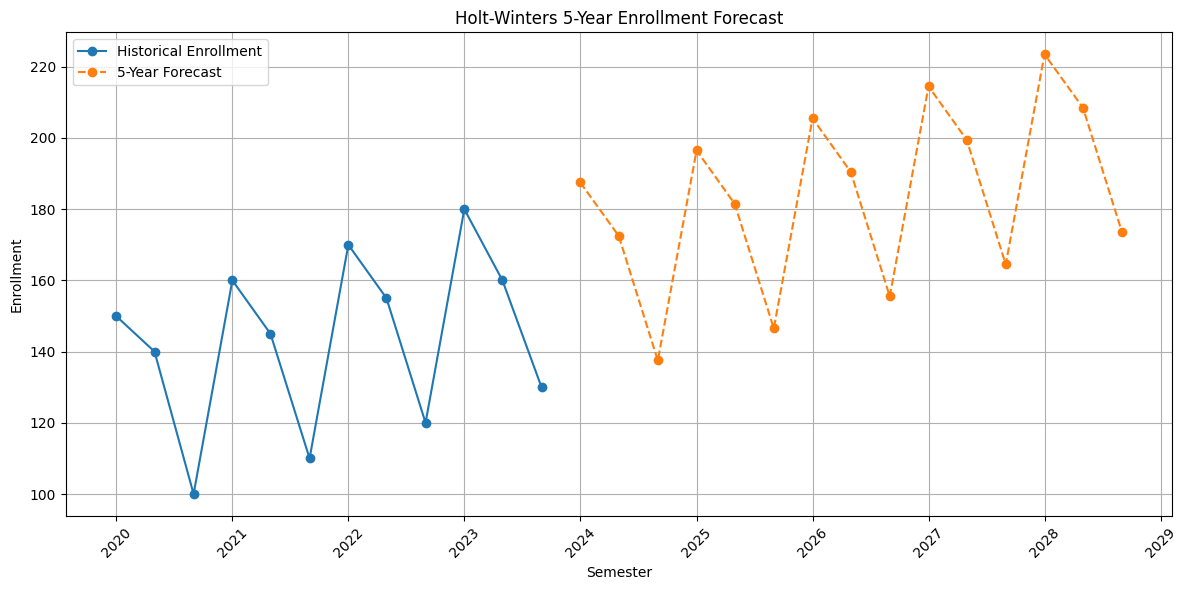

In [24]:
final_model = ExponentialSmoothing(
    df['Enrollment'],
    trend='add',
    seasonal='add',
    seasonal_periods=3
).fit()

forecast_5yr = final_model.forecast(15)


plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df['Enrollment'],
    marker='o',
    label='Historical Enrollment'
)

plt.plot(
    forecast_5yr.index,
    forecast_5yr.values,
    marker='o',
    linestyle='--',
    label='5-Year Forecast'
)

plt.title('Holt-Winters 5-Year Enrollment Forecast')
plt.xlabel('Semester')
plt.ylabel('Enrollment')

plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()